In [ ]:
import copernicusmarine

#copernicusmarine.subset(
#  dataset_id="cmems_mod_bal_phy_anfc_PT1H-i",
#  variables=["uo", "vo"],
#  minimum_longitude=8.988638320335978,
#  maximum_longitude=17.841361544682435,
#  minimum_latitude=53.66949836152353,
#  maximum_latitude=60.20994313174964,
#  start_datetime="2026-08-10T00:00:00",
#  end_datetime="2026-08-15T00:00:00",
#  minimum_depth=0.5016462206840515,
#  maximum_depth=148.90380859375,
#)

In [2]:
import xarray as xr

cmems_data = xr.open_dataset("./compare_data/cmems_mod_bal_phy_anfc_PT1H-i_uo-vo_9.04E-17.82E_53.67N-60.21N_0.50-148.90m_2026-08-10-2026-08-15.nc")

/home/ddyob/Documents/argo_piloting/model_tracker/.venv/bin/python: No module named pip


In [ ]:
cmems_data

In [3]:
fcoo_data = xr.open_dataset("./compare_data/August10FCOO_data.nc")
fcoo_data.time


<xarray.DataArray 'time' (time: 56)> Size: 448B
array(['2026-08-10T05:00:00.000000000', '2026-08-10T06:00:00.000000000',
       '2026-08-10T07:00:00.000000000', '2026-08-10T08:00:00.000000000',
       '2026-08-10T09:00:00.000000000', '2026-08-10T10:00:00.000000000',
       '2026-08-10T11:00:00.000000000', '2026-08-10T12:00:00.000000000',
       '2026-08-10T13:00:00.000000000', '2026-08-10T14:00:00.000000000',
       '2026-08-10T15:00:00.000000000', '2026-08-10T16:00:00.000000000',
       '2026-08-10T17:00:00.000000000', '2026-08-10T18:00:00.000000000',
       '2026-08-10T19:00:00.000000000', '2026-08-10T20:00:00.000000000',
       '2026-08-10T21:00:00.000000000', '2026-08-10T22:00:00.000000000',
       '2026-08-10T23:00:00.000000000', '2026-08-11T00:00:00.000000000',
       '2026-08-11T01:00:00.000000000', '2026-08-11T02:00:00.000000000',
       '2026-08-11T03:00:00.000000000', '2026-08-11T04:00:00.000000000',
       '2026-08-11T05:00:00.000000000', '2026-08-11T06:00:00.000000000',
       '2026-08-11T07:00:00.000000000', '2026-08-11T08:00:00.000000000',
       '2026-08-11T09:00:00.000000000', '2026-08-11T10:00:00.000000000',
       '2026-08-11T11:00:00.000000000', '2026-08-11T12:00:00.000000000',
       '2026-08-11T13:00:00.000000000', '2026-08-11T14:00:00.000000000',
       '2026-08-11T15:00:00.000000000', '2026-08-11T16:00:00.000000000',
       '2026-08-11T17:00:00.000000000', '2026-08-11T18:00:00.000000000',
       '2026-08-11T19:00:00.000000000', '2026-08-11T20:00:00.000000000',
       '2026-08-11T21:00:00.000000000', '2026-08-11T22:00:00.000000000',
       '2026-08-11T23:00:00.000000000', '2026-08-12T00:00:00.000000000',
       '2026-08-12T01:00:00.000000000', '2026-08-12T02:00:00.000000000',
       '2026-08-12T03:00:00.000000000', '2026-08-12T04:00:00.000000000',
       '2026-08-12T05:00:00.000000000', '2026-08-12T06:00:00.000000000',
       '2026-08-12T07:00:00.000000000', '2026-08-12T08:00:00.000000000',
       '2026-08-12T09:00:00.000000000', '2026-08-12T10:00:00.000000000',
       '2026-08-12T11:00:00.000000000', '2026-08-12T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 448B 2026-08-10T05:00:00 ... 2026-08-12T12...
Attributes:
    long_name:      time
    time_origin:    2026-08-10 05:00:00
    standard_name:  time

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = "2026-08-11T00:00:00"

u = fcoo_data["uu_dk"].sel(time=time, method='nearest')
v = fcoo_data["vv_dk"].sel(time=time, method='nearest')
speed = np.sqrt(u**2 + v**2)

for z in speed.zax_dk:
    speed_for_plot = speed.sel(zax_dk = z, method = "nearest")
    fig, ax = plt.subplots(figsize=(8, 6))
    pcm = ax.pcolormesh(fcoo_data["lonc_dk"], fcoo_data["latc_dk"], speed_for_plot, shading='nearest', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Speed (m/s)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Current speed at {speed.time.values} at depth {np.array(z)}')
    plt.show()

In [ ]:
u = cmems_data["uo"].sel(time=time, method='nearest')
v = cmems_data["vo"].sel(time=time, method='nearest')
speed = np.sqrt(u**2 + v**2)

for z in speed.depth:
    speed_for_plot = speed.sel(depth = z, method = "nearest")
    fig, ax = plt.subplots(figsize=(8, 6))
    pcm = ax.pcolormesh(cmems_data["longitude"], cmems_data["latitude"], speed_for_plot, shading='nearest', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Speed (m/s)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Current speed at {speed.time.values} at depth {np.array(z)}')
    plt.show()

In [5]:
BBOX = {
    "lat_min" : 53.94469077302122,
    "lon_min" : 13.971302845450026,
    "lat_max" : 56.196934554488564,
    "lon_max" : 16.405848950140353
}

fcoo_subset = fcoo_data.sel(lonc_dk=slice(BBOX["lon_min"], BBOX["lon_max"]), latc_dk = slice(BBOX["lat_min"], BBOX["lat_max"]))
cmems_subset = cmems_data.sel(longitude=slice(BBOX["lon_min"], BBOX["lon_max"]), latitude = slice(BBOX["lat_min"], BBOX["lat_max"]))
cmems_subset = cmems_subset.sel(time = slice(min(fcoo_subset["time"]), max(fcoo_subset["time"])))


In [20]:
cmems_subset["speed"] = cmems_subset.uo**2 + cmems_subset.vo**2
fcoo_subset["speed"] = fcoo_subset.uu_dk**2 + fcoo_subset.vv_dk**2
cmems_subset["dir"] = (np.degrees(np.arctan2(cmems_subset["uo"], cmems_subset["vo"])) +360) % 360
fcoo_subset["dir"] = (np.degrees(np.arctan2(fcoo_subset["uu_dk"], fcoo_subset["vv_dk"])) +360) % 360

fcoo_subset["longitude"] = fcoo_subset["lonc_dk"]
fcoo_subset["latitude"] = fcoo_subset["latc_dk"]
fcoo_subset["depth"] = fcoo_subset["zax_dk"]
fcoo_subset["uo"] = fcoo_subset["uu_dk"]
fcoo_subset["vo"] = fcoo_subset["vv_dk"]

cmems_on_fcoo = cmems_subset.interp_like(fcoo_subset, method="linear")

#diff_u = cmems_on_fcoo["uo"] - fcoo_subset["uo"]
#diff_v = cmems_on_fcoo["vo"] - fcoo_subset["vo"]


ValueError: the new name 'longitude' conflicts

In [ ]:
times_for_diff = fcoo_subset.time.values
depths_for_diff = fcoo_subset.depth.values

for time_i in times_for_diff:
    for depth in depths_for_diff:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        fcoo_speed = fcoo_subset.sel(time=time_i, zax_dk = depth, method = "nearest")
        cmems_speed = cmems_subset.sel(time=time_i, depth = depth, method = "nearest")

        vmin = min(fcoo_speed["speed"].min(), cmems_speed["speed"].min())
        vmax = max(fcoo_speed["speed"].max(), cmems_speed["speed"].max())


        pcm_fcoo = ax1.pcolormesh(fcoo_speed["longitude"], fcoo_speed["latitude"], fcoo_speed["speed"],
                                   shading='nearest', cmap='viridis', vmin=vmin, vmax=vmax)
        pcm_cmems = ax2.pcolormesh(cmems_speed["longitude"], cmems_speed["latitude"], cmems_speed["speed"],
                                    shading='nearest', cmap='viridis', vmin=vmin, vmax=vmax)

        fig.colorbar(pcm_cmems, ax=[ax1, ax2], label='Speed (m/s)')
        fig.suptitle(f'Current speed at {time_i} at depth fcoo: {np.array(fcoo_speed["depth"])} and cmems depth: {np.array(cmems_speed["depth"])}')
        plt.show()

In [ ]:
times_for_diff = fcoo_subset.time.values
depths_for_diff = fcoo_subset.depth.values

for time_i in times_for_diff:
    for depth in depths_for_diff:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        (ax1, ax2), (ax3, ax4) = axes

        fcoo_sel = fcoo_subset.sel(time=time_i, zax_dk=depth, method="nearest")
        cmems_sel = cmems_subset.sel(time=time_i, depth=depth, method="nearest")

        # --- speed ---
        vmin = min(fcoo_sel["speed"].min(), cmems_sel["speed"].min())
        vmax = max(fcoo_sel["speed"].max(), cmems_sel["speed"].max())

        pcm_fcoo = ax1.pcolormesh(fcoo_sel["longitude"], fcoo_sel["latitude"], fcoo_sel["speed"],
                                   shading='nearest', cmap='viridis', vmin=vmin, vmax=vmax)
        pcm_cmems = ax2.pcolormesh(cmems_sel["longitude"], cmems_sel["latitude"], cmems_sel["speed"],
                                    shading='nearest', cmap='viridis', vmin=vmin, vmax=vmax)
        fig.colorbar(pcm_cmems, ax=[ax1, ax2], label='Speed (m/s)')

        # --- direction (degrees, 0-360, from u/v) ---

        pcm_fcoo_dir = ax3.pcolormesh(fcoo_sel["longitude"], fcoo_sel["latitude"], fcoo_sel["dir"],
                                       shading='nearest', cmap='twilight', vmin=0, vmax=360)
        pcm_cmems_dir = ax4.pcolormesh(cmems_sel["longitude"], cmems_sel["latitude"], cmems_sel["dir"],
                                        shading='nearest', cmap='twilight', vmin=0, vmax=360)
        fig.colorbar(pcm_cmems_dir, ax=[ax3, ax4], label='Direction (° from East, CCW)')

        for ax, title in zip([ax1, ax2, ax3, ax4],
                              ['FCOO speed', 'CMEMS speed', 'FCOO direction', 'CMEMS direction']):
            ax.set_title(title)
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')

        fig.suptitle(f'{time_i} — depth fcoo: {np.array(fcoo_sel["depth"])}, cmems: {np.array(cmems_sel["depth"])}')
        plt.tight_layout()
        plt.show()

In [ ]:
import os

outdir = "./compare_data"

times_for_diff = fcoo_subset.time.values
depths_for_diff = fcoo_subset.depth.values

for time_i in times_for_diff:
    for depth in depths_for_diff:
        fcoo_sub = fcoo_subset.sel(time=time_i, zax_dk=depth, method="nearest")
        cmems_sub = cmems_subset.sel(time=time_i, depth=depth, method="nearest")

        # --- interpolate CMEMS onto FCOO grid, compute difference ---
        cmems_on_fcoo = cmems_sub.interp(
            longitude=fcoo_sub["longitude"],
            latitude=fcoo_sub["latitude"],
            method="linear"
        )

        diff_u = (cmems_on_fcoo["uo"] - fcoo_sub["uu_dk"]).squeeze()
        diff_v = (cmems_on_fcoo["vo"] - fcoo_sub["vv_dk"]).squeeze()
        diff_speed = np.sqrt(diff_u**2 + diff_v**2)

        # --- shared color scale for the top row ---
        vmin = min(fcoo_sub["speed"].min(), cmems_sub["speed"].min())
        vmax = max(fcoo_sub["speed"].max(), cmems_sub["speed"].max())

        # --- layout: 2 plots on top, 1 big plot below ---
        fig = plt.figure(figsize=(12, 14))
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.4])
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, :])

        quiver_kwargs = dict(scale=7, scale_units='inches', width=0.005, cmap='viridis')

        q_fcoo = ax1.quiver(fcoo_sub["longitude"], fcoo_sub["latitude"],
                             fcoo_sub["uu_dk"], fcoo_sub["vv_dk"], fcoo_sub["speed"],
                             clim=(vmin, vmax), **quiver_kwargs)
        ax1.set_title("FCOO velocity")
        ax1.set_xlabel("Longitude")
        ax1.set_ylabel("Latitude")
        #fig.colorbar(q_fcoo, ax=ax1, label="Speed (m/s)", fraction=0.046, pad=0.04)

        q_cmems = ax2.quiver(cmems_sub["longitude"], cmems_sub["latitude"],
                              cmems_sub["uo"], cmems_sub["vo"], cmems_sub["speed"],
                              clim=(vmin, vmax), **quiver_kwargs)
        ax2.set_title("CMEMS velocity")
        ax2.set_xlabel("Longitude")
        ax2.set_ylabel("Latitude")
        fig.colorbar(q_cmems, ax=ax2, label="Speed (m/s)", fraction=0.046, pad=0.04)

        # --- big difference plot ---
        diff_quiver_kwargs = dict(scale=1.2, scale_units='inches', width=0.006, cmap='magma')
        q_diff = ax3.quiver(fcoo_sub["lonc_dk"], fcoo_sub["latc_dk"],
                         diff_u, diff_v, diff_speed, **diff_quiver_kwargs)
        ax3.set_title("Velocity difference (CMEMS interpolated onto FCOO grid − FCOO)")
        ax3.set_xlabel("Longitude")
        ax3.set_ylabel("Latitude")
        fig.colorbar(q_diff, ax=ax3, label="Difference speed (m/s)", fraction=0.023, pad=0.02)

        # reference arrow so arrow length is interpretable
        ax3.quiverkey(q_diff, X=0.9, Y=1.05, U=0.2, label='0.2 m/s', labelpos='E')

        fig.suptitle(
            f'{np.datetime_as_string(time_i, unit="h")} — '
            f'depth fcoo: {float(fcoo_sub["depth"]):.1f} m, cmems: {float(cmems_sub["depth"]):.1f} m',
            fontsize=14
        )
        plt.tight_layout()

        # --- save with time and depth in filename ---
        time_str = np.datetime_as_string(time_i, unit="h").replace(":", "").replace("-", "")
        depth_str = f'{float(fcoo_sub["depth"]):.0f}m'
        fname = os.path.join(outdir, f"velocity_diff_{time_str}_{depth_str}.png")
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        print(diff_speed.min().values, diff_speed.max().values, diff_speed.mean().values)
        plt.show()
        plt.close(fig)

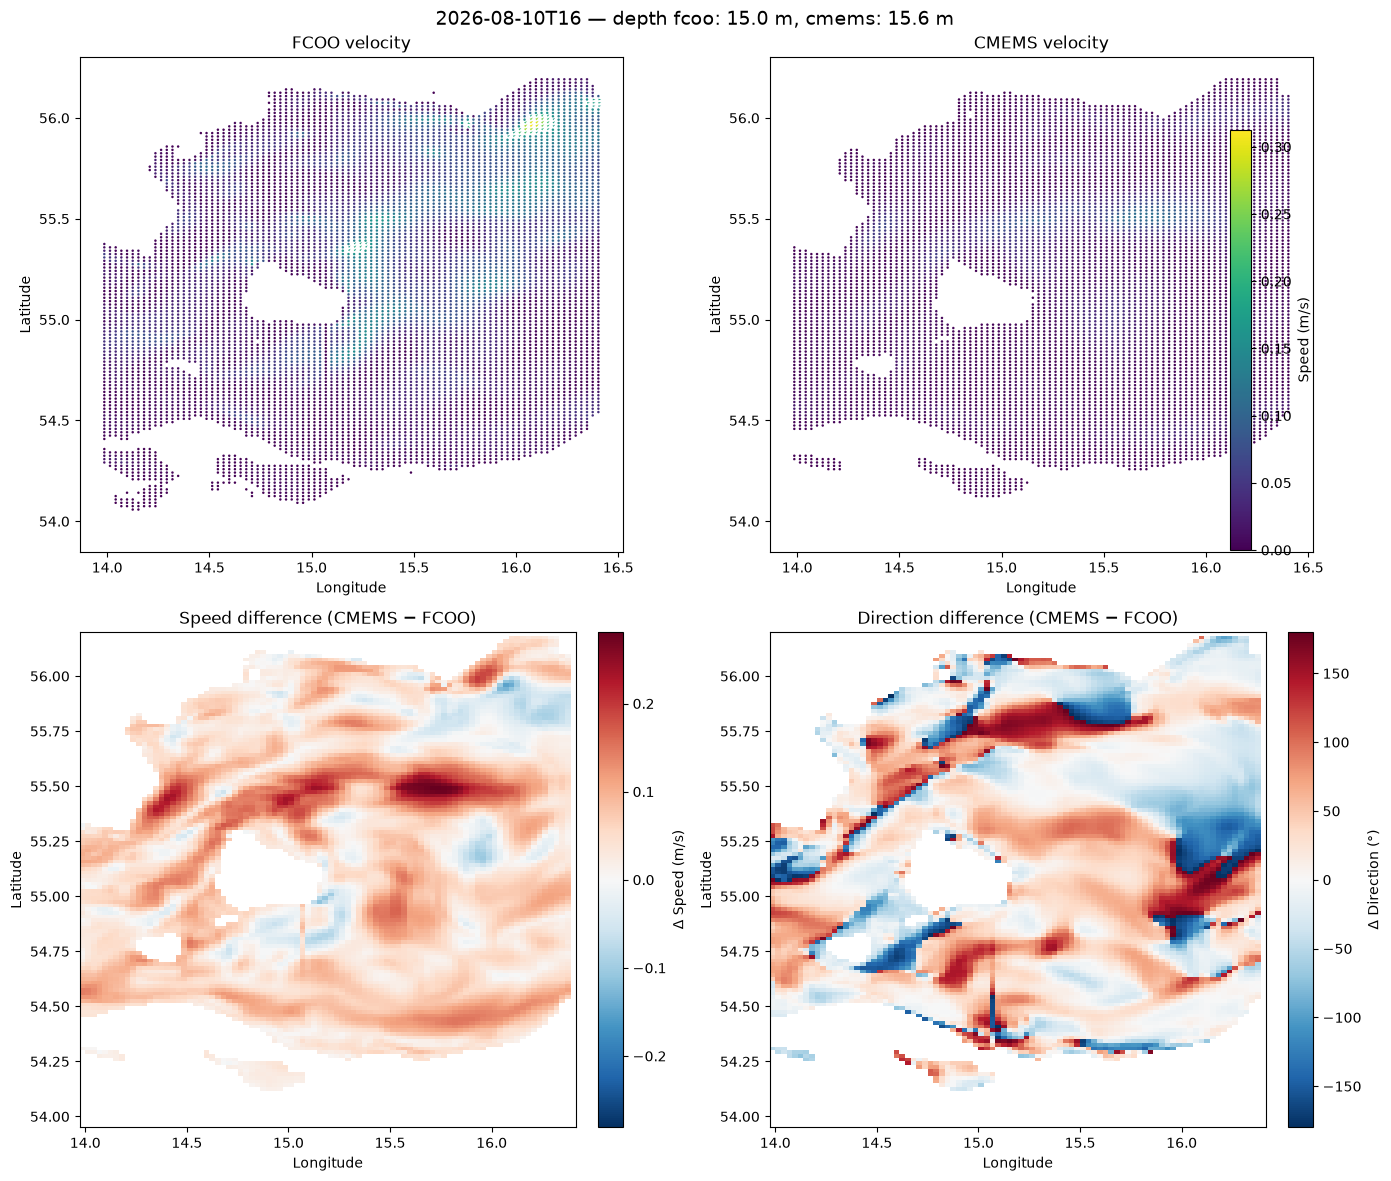

/tmp/ipykernel_14753/1278023128.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


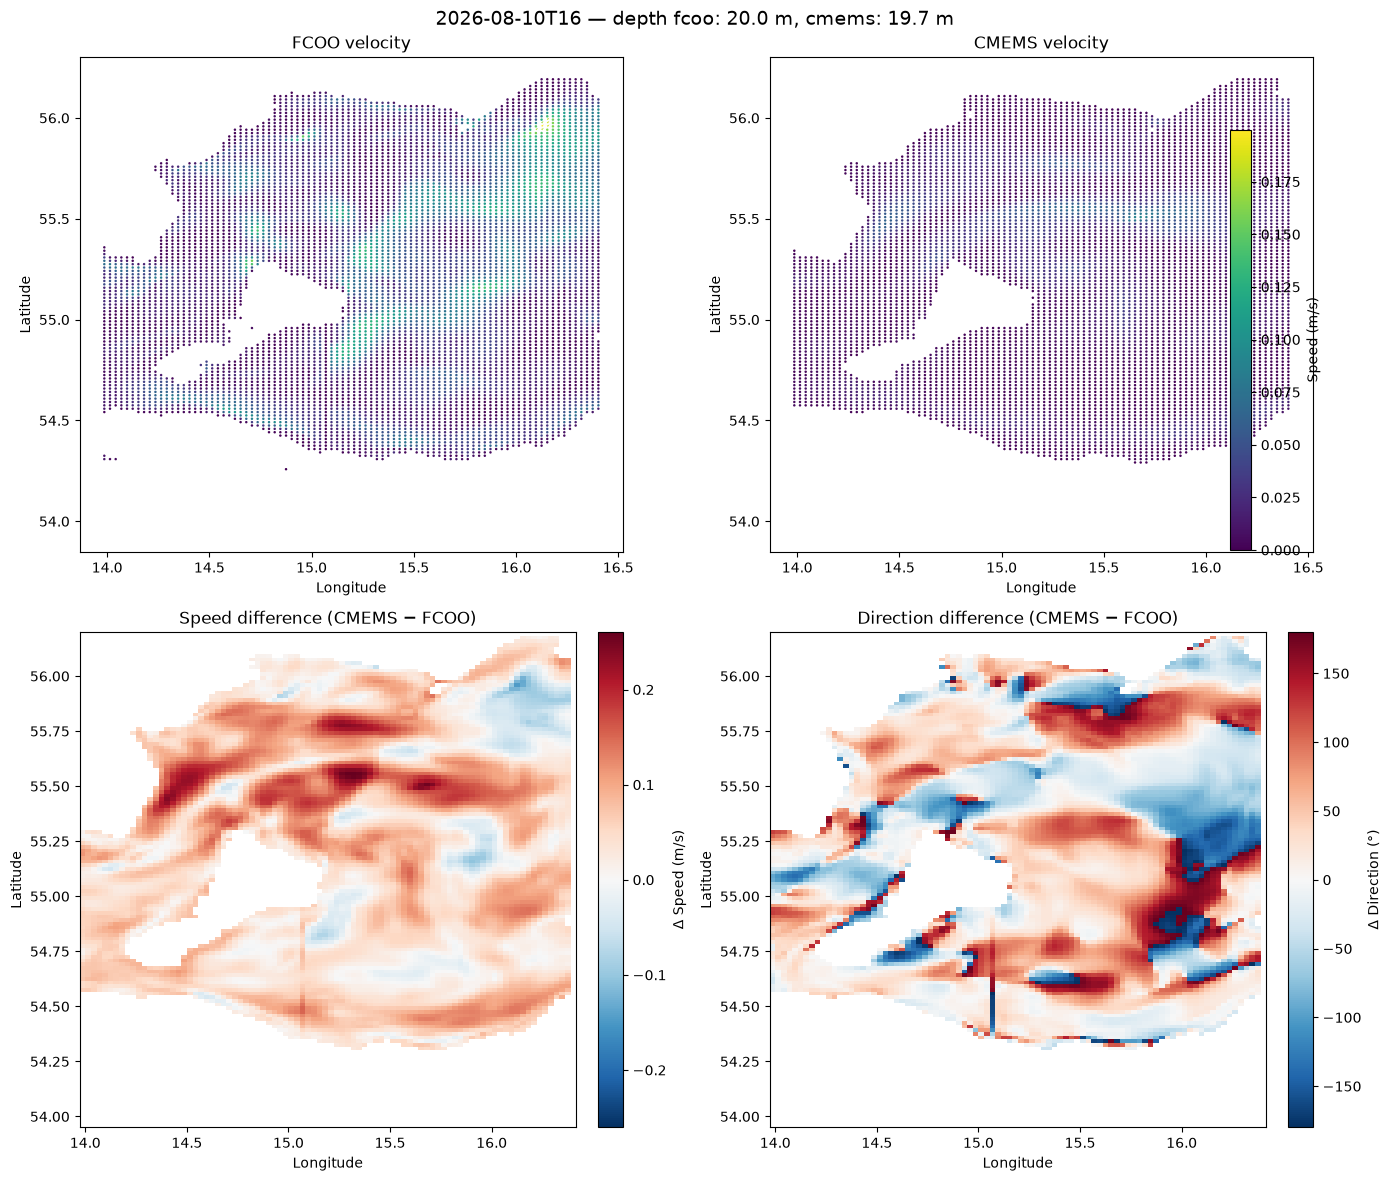

/tmp/ipykernel_14753/1278023128.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


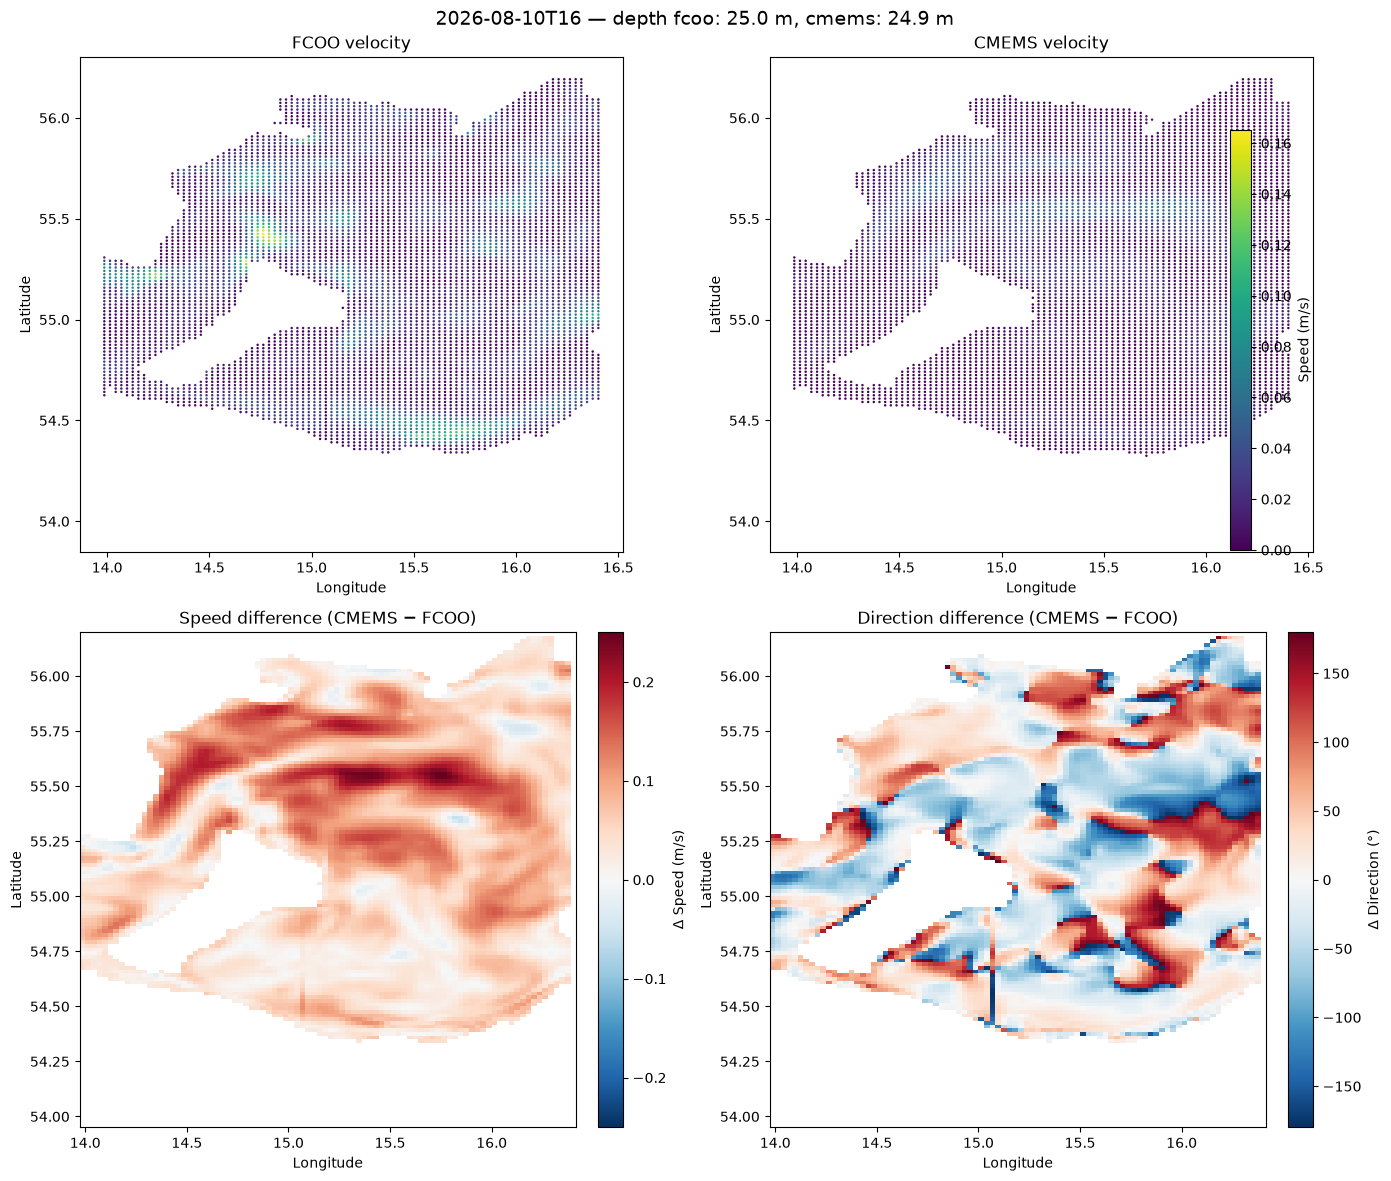

/tmp/ipykernel_14753/1278023128.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


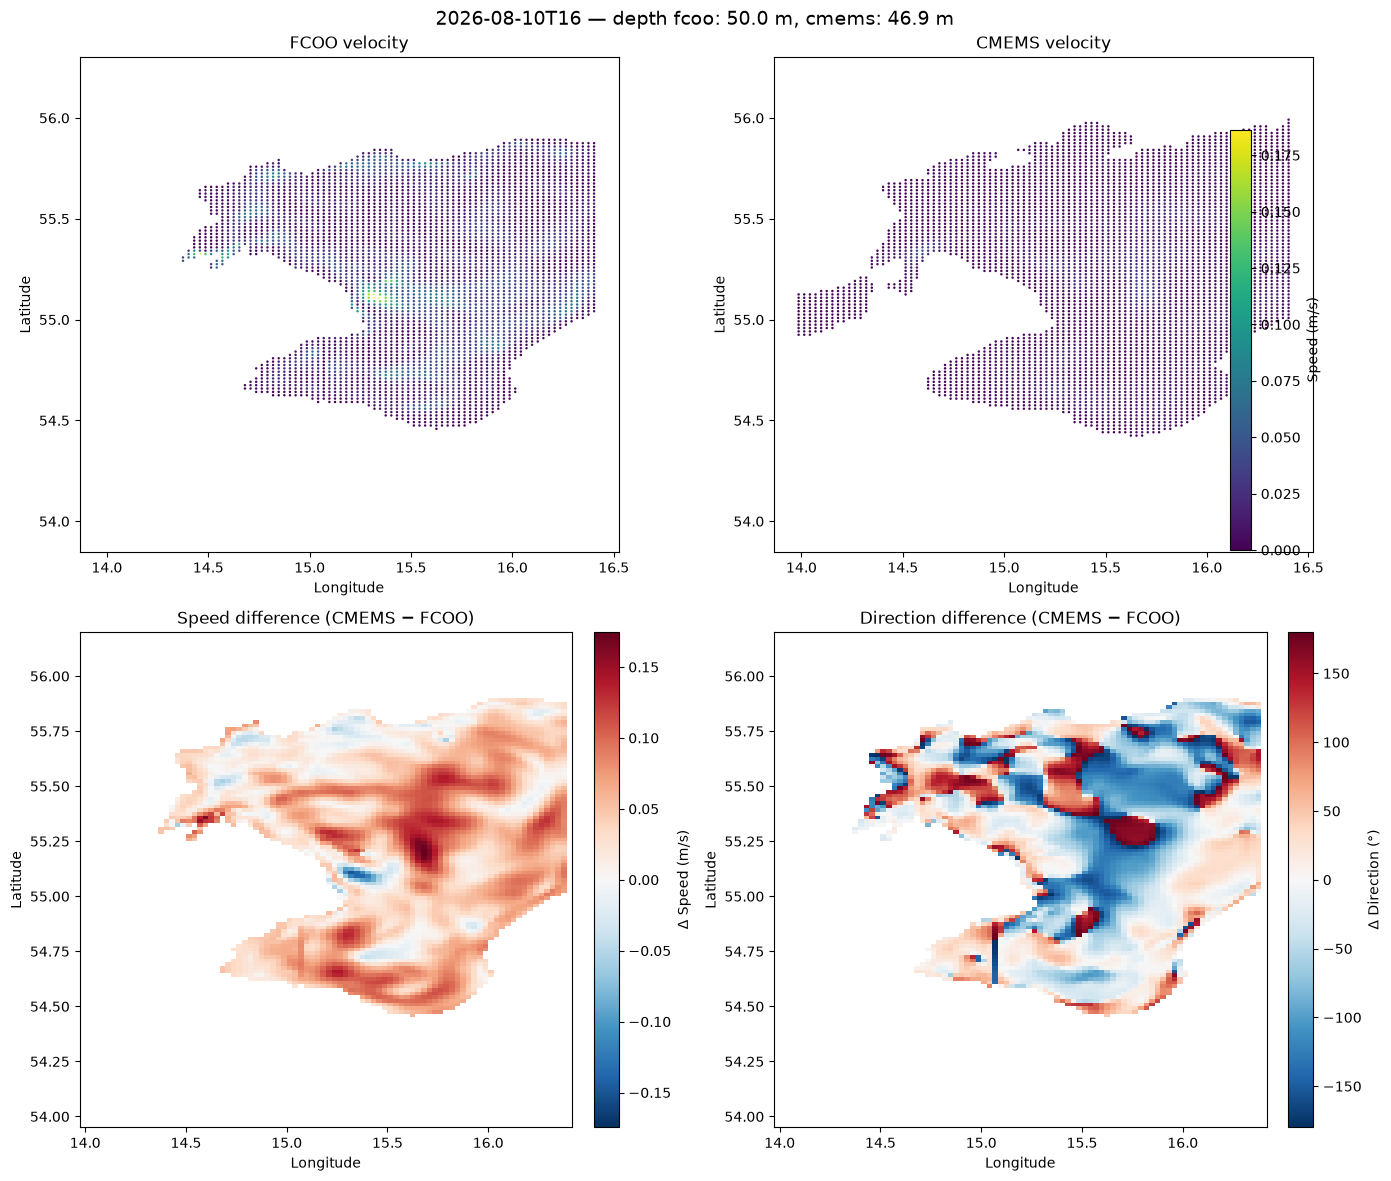

/tmp/ipykernel_14753/1278023128.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


KeyboardInterrupt: 

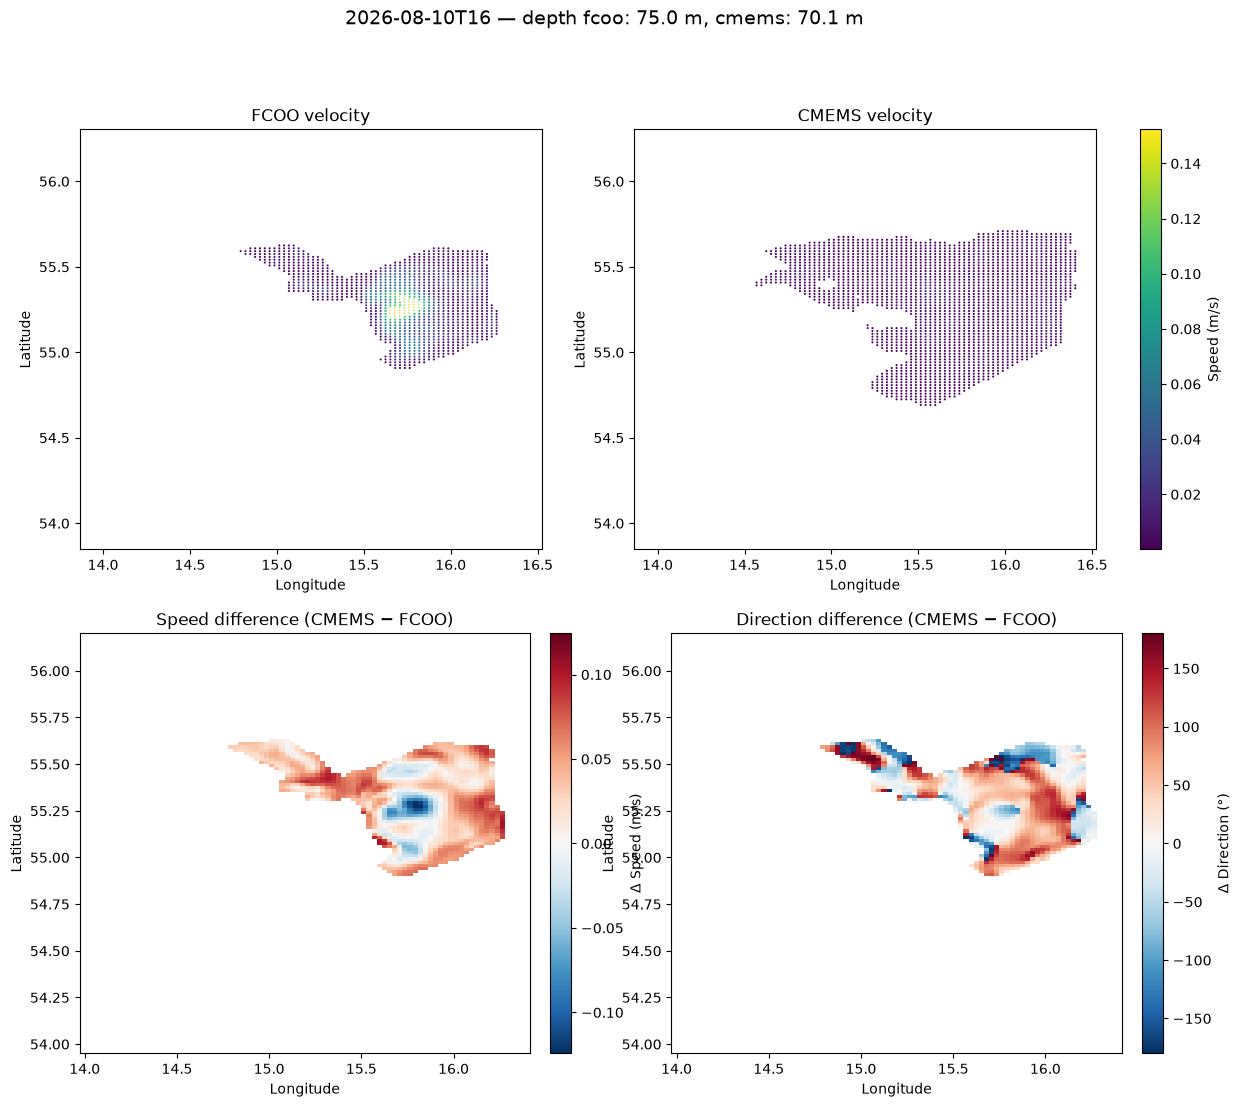

In [27]:
import os
outdir = "./compare_data"
times_for_diff = fcoo_subset.time.values
depths_for_diff = fcoo_subset.depth.values

for time_i in times_for_diff:
    for depth in depths_for_diff:
        fcoo_sub = fcoo_subset.sel(time=time_i, zax_dk=depth, method="nearest")
        cmems_sub = cmems_subset.sel(time=time_i, depth=depth, method="nearest")

        # --- interpolate CMEMS onto FCOO grid ---
        cmems_on_fcoo = cmems_sub.interp(
            longitude=fcoo_sub["longitude"],
            latitude=fcoo_sub["latitude"],
            method="linear"
        )

        cmems_speed_i = np.sqrt(cmems_on_fcoo["uo"]**2 + cmems_on_fcoo["vo"]**2).squeeze()
        cmems_dir_i = (np.degrees(np.arctan2(cmems_on_fcoo["vo"], cmems_on_fcoo["uo"])) + 360) % 360
        cmems_dir_i = cmems_dir_i.squeeze()

        fcoo_speed = fcoo_sub["speed"]
        fcoo_dir = (np.degrees(np.arctan2(fcoo_sub["vv_dk"], fcoo_sub["uu_dk"])) + 360) % 360

        # --- differences ---
        diff_speed_scalar = cmems_speed_i - fcoo_speed
        diff_dir = ((cmems_dir_i - fcoo_dir + 180) % 360) - 180  # wrapped to [-180, 180]

        # --- shared color scale for the top row (velocity magnitude) ---
        vmin = min(fcoo_sub["speed"].min(), cmems_sub["speed"].min())
        vmax = max(fcoo_sub["speed"].max(), cmems_sub["speed"].max())

        # --- layout: 2 quiver plots on top, 2 diff plots on bottom ---
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

        quiver_kwargs = dict(scale=15, scale_units='inches', width=0.005, cmap='viridis')
        q_fcoo = ax1.quiver(fcoo_sub["longitude"], fcoo_sub["latitude"],
                             fcoo_sub["uu_dk"], fcoo_sub["vv_dk"], fcoo_sub["speed"],
                             clim=(vmin, vmax), **quiver_kwargs)
        ax1.set_title("FCOO velocity")
        ax1.set_xlabel("Longitude")
        ax1.set_ylabel("Latitude")

        q_cmems = ax2.quiver(cmems_sub["longitude"], cmems_sub["latitude"],
                              cmems_sub["uo"], cmems_sub["vo"], cmems_sub["speed"],
                              clim=(vmin, vmax), **quiver_kwargs)
        ax2.set_title("CMEMS velocity")
        ax2.set_xlabel("Longitude")
        ax2.set_ylabel("Latitude")
        fig.colorbar(q_cmems, ax=[ax1, ax2], label="Speed (m/s)", fraction=0.023, pad=0.04)

        # --- bottom left: speed difference ---
        speed_diff_max = np.abs(diff_speed_scalar).max()
        pcm_speed_diff = ax3.pcolormesh(fcoo_sub["lonc_dk"], fcoo_sub["latc_dk"], diff_speed_scalar,
                                         shading='nearest', cmap='RdBu_r',
                                         vmin=-speed_diff_max, vmax=speed_diff_max)
        ax3.set_title("Speed difference (CMEMS − FCOO)")
        ax3.set_xlabel("Longitude")
        ax3.set_ylabel("Latitude")
        fig.colorbar(pcm_speed_diff, ax=ax3, label="Δ Speed (m/s)", fraction=0.046, pad=0.04)

        # --- bottom right: direction difference ---
        pcm_dir_diff = ax4.pcolormesh(fcoo_sub["lonc_dk"], fcoo_sub["latc_dk"], diff_dir,
                                       shading='nearest', cmap='RdBu_r', vmin=-180, vmax=180)
        ax4.set_title("Direction difference (CMEMS − FCOO)")
        ax4.set_xlabel("Longitude")
        ax4.set_ylabel("Latitude")
        fig.colorbar(pcm_dir_diff, ax=ax4, label="Δ Direction (°)", fraction=0.046, pad=0.04)

        fig.suptitle(
            f'{np.datetime_as_string(time_i, unit="h")} — '
            f'depth fcoo: {float(fcoo_sub["depth"]):.1f} m, cmems: {float(cmems_sub["depth"]):.1f} m',
            fontsize=14
        )
        plt.tight_layout()

        # --- save with time and depth in filename ---
        time_str = np.datetime_as_string(time_i, unit="h").replace(":", "").replace("-", "")
        depth_str = f'{float(fcoo_sub["depth"]):.0f}m'
        fname = os.path.join(outdir, f"velocity_diff_{time_str}_{depth_str}.png")
        fig.savefig(fname, dpi=150, bbox_inches="tight")

        plt.show()
        plt.close(fig)

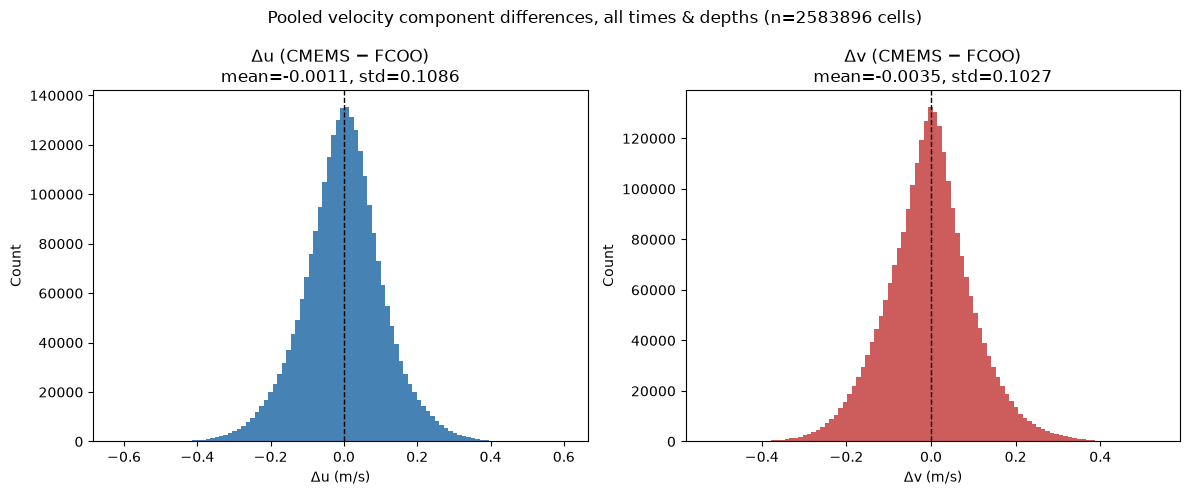

In [29]:
diff_u_all = []
diff_v_all = []

times_for_diff = fcoo_subset.time.values
depths_for_diff = fcoo_subset.depth.values

for time_i in times_for_diff:
    for depth in depths_for_diff:
        fcoo_sub = fcoo_subset.sel(time=time_i, zax_dk=depth, method="nearest")
        cmems_sub = cmems_subset.sel(time=time_i, depth=depth, method="nearest")

        cmems_on_fcoo = cmems_sub.interp(
            longitude=fcoo_sub["longitude"],
            latitude=fcoo_sub["latitude"],
            method="linear"
        )

        diff_u = (cmems_on_fcoo["uo"] - fcoo_sub["uu_dk"]).squeeze()
        diff_v = (cmems_on_fcoo["vo"] - fcoo_sub["vv_dk"]).squeeze()

        diff_u_all.append(diff_u.values.ravel())
        diff_v_all.append(diff_v.values.ravel())

# flatten everything into one long 1D array, dropping NaNs (land/coast mismatches)
diff_u_flat = np.concatenate(diff_u_all)
diff_v_flat = np.concatenate(diff_v_all)
diff_u_flat = diff_u_flat[~np.isnan(diff_u_flat)]
diff_v_flat = diff_v_flat[~np.isnan(diff_v_flat)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(diff_u_flat, bins=100, color='steelblue', edgecolor='none')
ax1.axvline(0, color='k', linestyle='--', linewidth=1)
ax1.set_title(f"Δu (CMEMS − FCOO)\nmean={diff_u_flat.mean():.4f}, std={diff_u_flat.std():.4f}")
ax1.set_xlabel("Δu (m/s)")
ax1.set_ylabel("Count")

ax2.hist(diff_v_flat, bins=100, color='indianred', edgecolor='none')
ax2.axvline(0, color='k', linestyle='--', linewidth=1)
ax2.set_title(f"Δv (CMEMS − FCOO)\nmean={diff_v_flat.mean():.4f}, std={diff_v_flat.std():.4f}")
ax2.set_xlabel("Δv (m/s)")
ax2.set_ylabel("Count")

fig.suptitle(f"Pooled velocity component differences, all times & depths (n={len(diff_u_flat)} cells)")
plt.tight_layout()
plt.show()

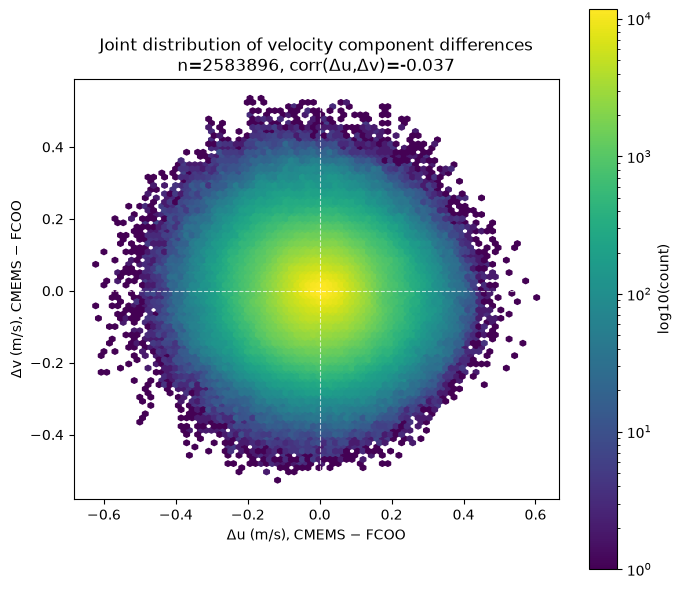

In [30]:
diff_u_all = []
diff_v_all = []

times_for_diff = fcoo_subset.time.values
depths_for_diff = fcoo_subset.depth.values

for time_i in times_for_diff:
    for depth in depths_for_diff:
        fcoo_sub = fcoo_subset.sel(time=time_i, zax_dk=depth, method="nearest")
        cmems_sub = cmems_subset.sel(time=time_i, depth=depth, method="nearest")

        cmems_on_fcoo = cmems_sub.interp(
            longitude=fcoo_sub["longitude"],
            latitude=fcoo_sub["latitude"],
            method="linear"
        )

        diff_u = (cmems_on_fcoo["uo"] - fcoo_sub["uu_dk"]).squeeze()
        diff_v = (cmems_on_fcoo["vo"] - fcoo_sub["vv_dk"]).squeeze()

        diff_u_all.append(diff_u.values.ravel())
        diff_v_all.append(diff_v.values.ravel())

diff_u_flat = np.concatenate(diff_u_all)
diff_v_flat = np.concatenate(diff_v_all)

mask = ~(np.isnan(diff_u_flat) | np.isnan(diff_v_flat))
diff_u_flat = diff_u_flat[mask]
diff_v_flat = diff_v_flat[mask]

fig, ax = plt.subplots(figsize=(7, 6))

hb = ax.hexbin(diff_u_flat, diff_v_flat, gridsize=80, cmap='viridis', mincnt=1, bins='log')
ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel("Δu (m/s), CMEMS − FCOO")
ax.set_ylabel("Δv (m/s), CMEMS − FCOO")
ax.set_aspect('equal')

corr = np.corrcoef(diff_u_flat, diff_v_flat)[0, 1]
ax.set_title(f"Joint distribution of velocity component differences\n"
             f"n={len(diff_u_flat)}, corr(Δu,Δv)={corr:.3f}")

fig.colorbar(hb, ax=ax, label="log10(count)")
plt.tight_layout()
plt.show()